# 📊 EDA & Preprocessing
**Projet ML 2026 — UMONS | Groupe 3**

Ce notebook couvre l'ensemble de la préparation des données :
- Chargement et exploration de chaque dataset
- Nettoyage et correction des problèmes identifiés
- Fusion de tous les datasets
- Analyse des corrélations
- Sauvegarde du dataset final prêt pour la modélisation

In [174]:
# Imports et configuration

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Paramètres d'affichage
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style="whitegrid")

# Dossier pour sauvegarder les figures
os.makedirs("../figures", exist_ok=True)


## Chargement des données
Chargement des 6 datasets fournis dans le cadre du projet :
- `results_train / test` : résultats du référendum
- `je-e-21.03.01` : données démographiques, géographiques et économiques
- `revenus` : données fiscales et de revenus par commune (2017)
- `geodata` : coordonnées GPS des communes
- `622.00` : résultats d'un référendum précédent (souveraineté alimentaire)

In [175]:
# Chargement des datasets

# Train & Test
train = pd.read_csv("../data/results_train.csv")
test  = pd.read_csv("../data/results_test.csv")

# Données démographiques, géographiques, économiques
demo = pd.read_excel(
    "../data/je-e-21.03.01.xlsx",
    sheet_name="Schweiz - Gemeinden",
    header=5
)
demo.columns = demo.columns.str.strip()

# Géolocalisation
geo = pd.read_csv("../data/swiss_communes_geodata.csv")

# Revenus 2017
legende = pd.read_excel(
    "../data/statistik-dbst-np-kennzahlen-mit-2017-fr.xlsx",
    sheet_name="Légende",
    header=1
)
col_names = legende["Variables"].dropna().tolist()[:22]

revenus = pd.read_excel(
    "../data/statistik-dbst-np-kennzahlen-mit-2017-fr.xlsx",
    sheet_name="Gemeinden - Communes",
    header=1
)

# Nettoyage du dataset des revenus, on filtre pour ne garder que le total par commune
# On convertit la colonne d'identifiant en numérique errors="coerce" -> mets les valeurs non convertibles à NaN, 
# puis on drop les lignes avec NaN et on convertit en int

revenus.columns = col_names # recupération des noms de colonnes depuis la légende
revenus = revenus[revenus["Einheit"] == "Total"].reset_index(drop=True)
revenus["gdenr"] = pd.to_numeric(revenus["gdenr"], errors="coerce")
revenus = revenus.dropna(subset=["gdenr"])
revenus["gdenr"] = revenus["gdenr"].astype(int)

# Référendum précédent
ref_prev = pd.read_excel(
    "../data/622.00-result-by-canton-district-and-municipality.xlsx",
    sheet_name="Gemeinden",
    header=5
)

# Affichons le résultat du chargement
print("Datasets chargés")
print(f"Train      : {train.shape}")
print(f"Test       : {test.shape}")
print(f"Demo       : {demo.shape}")
print(f"Revenus    : {revenus.shape}")
print(f"Géo        : {geo.shape}")
print(f"Réf. préc. : {ref_prev.shape}")

Datasets chargés
Train      : (1559, 13)
Test       : (669, 5)
Demo       : (2261, 43)
Revenus    : (2254, 22)
Géo        : (2351, 4)
Réf. préc. : (2235, 13)


## Train : Exploration et nettoyage
On explore le dataset principal, on identifie les colonnes de leakage
et on prépare le dataset pour le merge final.

In [176]:
# Exploration du Train
# On recherche les colonnes communes, l'identifiant et les colonnes inutiles ou redondantes

print("=== Dimensions ===")
print(f"Train : {train.shape}")

print("\n=== Colonnes et types ===")
print(train.dtypes)

print("\n=== Valeurs manquantes ===")
print(train.isnull().sum())

print("\n=== Aperçu ===")
print(train.head(3))

print("\n=== Statistiques descriptives ===")
print(train.describe())

=== Dimensions ===
Train : (1559, 13)

=== Colonnes et types ===
Kantons-Nummer              int64
Kanton                        str
Gemeinde-Nummer             int64
Gemeinde                      str
Stimmberechtigte          float64
eingelegte Stimmzettel    float64
Stimmbeteiligung          float64
leere Stimmzettel         float64
ungültige Stimmzettel     float64
gültige Stimmen           float64
Ja-Stimmen                float64
Nein-Stimmen              float64
Ja in Prozent             float64
dtype: object

=== Valeurs manquantes ===
Kantons-Nummer            0
Kanton                    0
Gemeinde-Nummer           0
Gemeinde                  0
Stimmberechtigte          0
eingelegte Stimmzettel    0
Stimmbeteiligung          0
leere Stimmzettel         0
ungültige Stimmzettel     0
gültige Stimmen           0
Ja-Stimmen                0
Nein-Stimmen              0
Ja in Prozent             0
dtype: int64

=== Aperçu ===
   Kantons-Nummer               Kanton  Gemeinde-Nummer   

In [177]:
#  Identification du leakage

# Corrélation de chaque colonne numérique avec la cible
print("=== Corrélations avec Ja in Prozent ===")
correlations = train.select_dtypes(include=np.number).corr()["Ja in Prozent"]
print(correlations.sort_values(ascending=False))

# Vérification mathématique
#train["check"] = (train["Ja-Stimmen"] / train["gültige Stimmen"] * 100).round(2)
#print("\n=== Preuve mathématique du leakage ===")
#print(train[["Ja-Stimmen", "gültige Stimmen", "Ja in Prozent", "check"]].head(5))
#train = train.drop(columns=["check"])

=== Corrélations avec Ja in Prozent ===
Ja in Prozent            1.00
Ja-Stimmen               0.15
Stimmberechtigte         0.14
leere Stimmzettel        0.14
eingelegte Stimmzettel   0.13
gültige Stimmen          0.13
ungültige Stimmzettel    0.11
Nein-Stimmen             0.11
Kantons-Nummer           0.04
Gemeinde-Nummer          0.04
Stimmbeteiligung         0.01
Name: Ja in Prozent, dtype: float64


In [178]:
# Nettoyage du Train

leakage_cols = [
    "Ja-Stimmen",
    "Nein-Stimmen",
    "gültige Stimmen",
    "eingelegte Stimmzettel",
    "leere Stimmzettel",
    "ungültige Stimmzettel",
    "Stimmbeteiligung"
]

train = train.drop(columns=[col for col in leakage_cols if col in train.columns])
train = train.rename(columns={"Gemeinde-Nummer": "commune_id"})
test  = test.rename(columns={"Gemeinde-Nummer": "commune_id"})

print(f"Train nettoyé : {train.shape}")
print(f"Colonnes : {train.columns.tolist()}")

Train nettoyé : (1559, 6)
Colonnes : ['Kantons-Nummer', 'Kanton', 'commune_id', 'Gemeinde', 'Stimmberechtigte', 'Ja in Prozent']


## Analyse de la variable cible : Ja in Prozent
On examine la distribution du pourcentage de votes OUI pour comprendre
ce qu'on cherche à prédire.

=== Statistiques descriptives ===
count   1559.00
mean      40.91
std       10.26
min        9.52
25%       34.15
50%       41.26
75%       47.21
max       88.57
Name: Ja in Prozent, dtype: float64


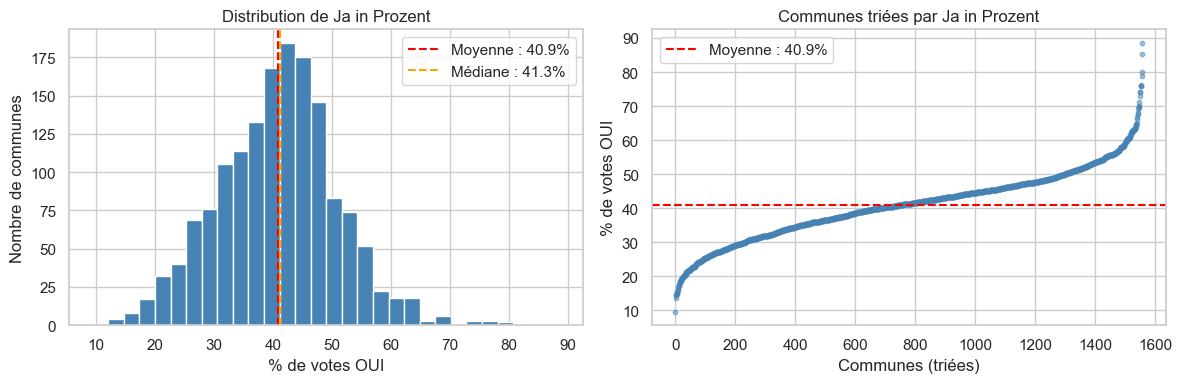

In [179]:
# Cellule 4 - Analyse de la variable cible

y = train["Ja in Prozent"]

print("=== Statistiques descriptives ===")
print(y.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme
axes[0].hist(y, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution de Ja in Prozent")
axes[0].set_xlabel("% de votes OUI")
axes[0].set_ylabel("Nombre de communes")
axes[0].axvline(y.mean(), color="red", linestyle="--", label=f"Moyenne : {y.mean():.1f}%")
axes[0].axvline(y.median(), color="orange", linestyle="--", label=f"Médiane : {y.median():.1f}%")
axes[0].legend()

# Scatter plot - communes triées
axes[1].scatter(range(len(y)), y.sort_values().values,
                color="steelblue", alpha=0.5, s=10)
axes[1].axhline(y.mean(), color="red", linestyle="--", label=f"Moyenne : {y.mean():.1f}%")
axes[1].set_title("Communes triées par Ja in Prozent")
axes[1].set_xlabel("Communes (triées)")
axes[1].set_ylabel("% de votes OUI")
axes[1].legend()

plt.tight_layout()
plt.savefig("../figures/target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Demo : Exploration et nettoyage
Dataset démographique, géographique et économique par commune (2018).

In [ ]:
# Exploration du Demo

print("=== Dimensions ===")
print(f"Demo : {demo.shape}")

print("\n=== 5 premières lignes ===")
print(demo.head(5).to_string())

print("\n=== Types de colonnes ===")
print(demo.dtypes.value_counts())

print("\n=== Valeurs manquantes ===")
missing = demo.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

# Vérification des colonnes potentiellement dupliquées
print("\n=== Primary sector vs Primary sector.1 ===")
print(demo[["Primary sector", "Primary sector.1"]].head(5))

print("\n=== Secondary sector vs Secondary sector.1 ===")
print(demo[["Secondary sector", "Secondary sector.1"]].head(5))

print("\n=== Tertiary sector vs Tertiary sector.1 ===")
print(demo[["Tertiary sector", "Tertiary sector.1"]].head(5))

print("\nSont-elles identiques ?")
print(f"Primary   : {demo['Primary sector'].equals(demo['Primary sector.1'])}")
print(f"Secondary : {demo['Secondary sector'].equals(demo['Secondary sector.1'])}")
print(f"Tertiary  : {demo['Tertiary sector'].equals(demo['Tertiary sector.1'])}")

=== Dimensions ===
Demo : (2261, 43)

=== 5 premières lignes ===
  Number of commune     Name of commune  Residents Change in %  Population density per km²  Foreign nationals in %  0-19 years  20-64 years  65 years or over  Crude marriage rate  Crude divorce rate  Crude birth rate  Crude mortality rate  Private households  Size of households in persons Total surface area in km2 Settlement and urban area in %     Change in ha Agricultural area in %   Change in ha.1 Wooded area in % Unproductive area in % Employed total Primary sector Secondary sector Tertiary sector Business establishments total Primary sector.1 Secondary sector.1 Tertiary sector.1  Dwelling vacancy rate  New housing units per 1000 residents Social assistance rate FDP/PLR 2)   CVP    SP   SVP EVP/CSP   GLP   BDP PdA/Sol.   GPS Small right-wing parties
0               NaN                 NaN    2016.00   2010-2016                     2016.00                 2016.00     2016.00      2016.00           2016.00              

In [181]:
# Nettoyage du Demo

# Supprimer les 3 premières lignes (métadonnées + total Suisse)
demo = demo.iloc[3:].reset_index(drop=True)

# Supprimer les lignes sans Id commune
demo = demo.dropna(subset=["Number of commune"]).reset_index(drop=True)

# Convertir Number of commune en entier
demo["Number of commune"] = pd.to_numeric(demo["Number of commune"], errors="coerce")
demo = demo.dropna(subset=["Number of commune"])
demo["Number of commune"] = demo["Number of commune"].astype(int)

# Convertir toutes les colonnes object en numérique si possible
for col in demo.columns:
    if demo[col].dtype == "object" and col != "Name of commune":
        demo[col] = pd.to_numeric(demo[col], errors="coerce")

# Renommer l'Id pour harmoniser
demo = demo.rename(columns={"Number of commune": "commune_id"})

# Renommer les colonnes .1 pour clarifier leur signification
# sector = nombre d'employés | sector.1 = nombre d'établissements
demo = demo.rename(columns={
    "Primary sector.1"   : "Primary sector establishments",
    "Secondary sector.1" : "Secondary sector establishments",
    "Tertiary sector.1"  : "Tertiary sector establishments"
})

# Supprimer la colonne nom (déjà dans train)
demo = demo.drop(columns=["Name of commune"])

print(f" Demo nettoyé : {demo.shape}")
print(f"Colonnes : {demo.columns.tolist()}")
print(f"Valeurs manquantes : {demo.isnull().sum().sum()}")


 Demo nettoyé : (2240, 42)
Colonnes : ['commune_id', 'Residents', 'Change in %', 'Population density per km²', 'Foreign nationals in %', '0-19 years', '20-64 years', '65 years or over', 'Crude marriage rate', 'Crude divorce rate', 'Crude birth rate', 'Crude mortality rate', 'Private households', 'Size of households in persons', 'Total surface area in km2', 'Settlement and urban area in %', 'Change in ha', 'Agricultural area in %', 'Change in ha.1', 'Wooded area in %', 'Unproductive area in %', 'Employed total', 'Primary sector', 'Secondary sector', 'Tertiary sector', 'Business establishments total', 'Primary sector establishments', 'Secondary sector establishments', 'Tertiary sector establishments', 'Dwelling vacancy rate', 'New housing units per 1000 residents', 'Social assistance rate', 'FDP/PLR 2)', 'CVP', 'SP', 'SVP', 'EVP/CSP', 'GLP', 'BDP', 'PdA/Sol.', 'GPS', 'Small right-wing parties']
Valeurs manquantes : 4382


## Revenus : Exploration et nettoyage
Dataset contenant les données fiscales et de revenus par commune (2017).

In [182]:
# Exploration des Revenus

print("=== Dimensions ===")
print(f"Revenus : {revenus.shape}")

print("\n=== Colonnes ===")
print(revenus.columns.tolist())

print("\n=== Aperçu ===")
print(revenus.head(3))

print("\n=== Valeurs manquantes ===")
missing = revenus.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

=== Dimensions ===
Revenus : (2254, 22)

=== Colonnes ===
['ktnr', 'ktname', 'gdenr', 'gdename', 'Einheit', 'stpf', 'snpstbetr', 'mean_stbetr', 'median_stbetr', 'gini_stbetr', 'mean_steink', 'median_steink', 'gini_steink', 'mean_steinka', 'median_steinka', 'gini_steinka', 'mean_reink', 'median_reink', 'gini_reink', 'mean_reinka', 'median_reinka', 'gini_reinka']

=== Aperçu ===
   ktnr ktname  gdenr               gdename Einheit  stpf  snpstbetr  \
0     1     ZH      2    Affoltern am Albis   Total  5385      10.74   
1     1     ZH      3            Bonstetten   Total  2457       7.55   
2     1     ZH      4       Hausen am Albis   Total  1613       5.67   

   mean_stbetr  median_stbetr  gini_stbetr  mean_steink  median_steink  \
0         1994            547         0.75        72583          58300   
1         3071            962         0.71        91002          75500   
2         3516            796         0.77        91766          69600   

   gini_steink  mean_steinka  medi

In [183]:
# Nettoyage des Revenus

# Renommer l'Id pour harmoniser
revenus = revenus.rename(columns={"gdenr": "commune_id"})

revenus = revenus.drop(columns=["ktnr", "ktname", "gdename", "Einheit"])

print(f"Revenus nettoyé : {revenus.shape}")
print(f"Colonnes : {revenus.columns.tolist()}")
print(f"Valeurs manquantes : {revenus.isnull().sum().sum()}")

Revenus nettoyé : (2254, 18)
Colonnes : ['commune_id', 'stpf', 'snpstbetr', 'mean_stbetr', 'median_stbetr', 'gini_stbetr', 'mean_steink', 'median_steink', 'gini_steink', 'mean_steinka', 'median_steinka', 'gini_steinka', 'mean_reink', 'median_reink', 'gini_reink', 'mean_reinka', 'median_reinka', 'gini_reinka']
Valeurs manquantes : 0


## Géolocalisation : Exploration et nettoyage
Dataset contenant les coordonnées GPS de chaque commune.

In [184]:
# Exploration du Géo

print("=== Dimensions ===")
print(f"Géo : {geo.shape}")

print("\n=== Colonnes ===")
print(geo.columns.tolist())

print("\n=== Aperçu ===")
print(geo.head(3))

print("\n=== Valeurs manquantes ===")
missing = geo.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

=== Dimensions ===
Géo : (2351, 4)

=== Colonnes ===
['bfs_id', 'municipalityLabel', 'lat', 'lon']

=== Aperçu ===
   bfs_id       municipalityLabel   lat  lon
0       1         Aeugst am Albis 47.27 8.49
1      10                Obfelden 47.26 8.42
2     100  Stadel bei Niederglatt 47.53 8.47

=== Valeurs manquantes ===
Series([], dtype: int64)


In [185]:
# Nettoyage du Géo

# Renommer l'Id pour harmoniser
geo = geo.rename(columns={"bfs_id": "commune_id"})

# Supprimer la colonne nom (déjà dans train)
geo = geo.drop(columns=["municipalityLabel"])

# Supprimer les doublons (mêmes coordonnées pour la même commune)
geo = geo.drop_duplicates(subset=["commune_id"]).reset_index(drop=True)

print(f"Géo nettoyé : {geo.shape}")
print(f"Colonnes : {geo.columns.tolist()}")
print(f"Valeurs manquantes : {geo.isnull().sum().sum()}")
print(geo.head(3))

Géo nettoyé : (2171, 3)
Colonnes : ['commune_id', 'lat', 'lon']
Valeurs manquantes : 0
   commune_id   lat  lon
0           1 47.27 8.49
1          10 47.26 8.42
2         100 47.53 8.47


## Référendum précédent : Exploration et nettoyage
Résultats du référendum "Initiative pour la souveraineté alimentaire" (2018).
Ce référendum précédent peut être un bon prédicteur du comportement de vote.

In [186]:
# Exploration du Réf. précédent

print("=== Dimensions ===")
print(f"Réf. préc. : {ref_prev.shape}")

print("\n=== Colonnes ===")
print(ref_prev.columns.tolist())

print("\n=== Aperçu ===")
print(ref_prev.head(3))

print("\n=== Valeurs manquantes ===")
missing = ref_prev.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

=== Dimensions ===
Réf. préc. : (2235, 13)

=== Colonnes ===
['Kantons-Nummer', 'Kanton', 'Gemeinde-Nummer', 'Gemeinde', 'Stimmberechtigte', 'eingelegte Stimmzettel', 'Stimmbeteiligung', 'leere Stimmzettel', 'ungültige Stimmzettel', 'gültige Stimmen', 'Ja-Stimmen', 'Nein-Stimmen', 'Ja in Prozent']

=== Aperçu ===
  Kantons-Nummer   Kanton Gemeinde-Nummer            Gemeinde  \
0                 Schweiz                                 NaN   
1              1   Zürich               1     Aeugst am Albis   
2              1   Zürich               2  Affoltern am Albis   

   Stimmberechtigte  eingelegte Stimmzettel  Stimmbeteiligung  \
0        5412449.00              2027998.00             37.47   
1           1402.00                  662.00             47.22   
2           7186.00                 2877.00             40.04   

   leere Stimmzettel  ungültige Stimmzettel  gültige Stimmen  Ja-Stimmen  \
0           34006.00                6797.00       1987195.00   628301.00   
1          

In [187]:
# Cellule 8b - Nettoyage du Réf. précédent

# Renommer l'Id pour harmoniser
ref_prev = ref_prev.rename(columns={"Gemeinde-Nummer": "commune_id"})

# Garder uniquement les colonnes utiles
ref_prev = ref_prev[["commune_id", "Ja in Prozent"]]
ref_prev = ref_prev.rename(columns={"Ja in Prozent": "ref622_ja_prozent"})

# Nettoyer les espaces et supprimer les lignes invalides
ref_prev["commune_id"] = ref_prev["commune_id"].astype(str).str.strip()
ref_prev = ref_prev[ref_prev["commune_id"] != ""].reset_index(drop=True)
ref_prev = ref_prev[ref_prev["commune_id"] != "nan"].reset_index(drop=True)

# Convertir commune_id en entier
ref_prev["commune_id"] = pd.to_numeric(ref_prev["commune_id"], errors="coerce")
ref_prev = ref_prev.dropna(subset=["commune_id"]).reset_index(drop=True)
ref_prev["commune_id"] = ref_prev["commune_id"].astype(int)

print(f" Réf. précédent nettoyé : {ref_prev.shape}")
print(f"Colonnes : {ref_prev.columns.tolist()}")
print(f"Valeurs manquantes : {ref_prev.isnull().sum().sum()}")
print(ref_prev.head(3))

 Réf. précédent nettoyé : (2228, 2)
Colonnes : ['commune_id', 'ref622_ja_prozent']
Valeurs manquantes : 0
   commune_id  ref622_ja_prozent
0           1              31.35
1           2              24.58
2           3              24.28


##  Merge de tous les datasets
On fusionne tous les datasets sur `commune_id` en utilisant un **left join** ( garde tout le train, NaN si pas de correspondance) :
- On part du `train` comme base
- On ajoute les informations de chaque dataset supplémentaire
- Un left join garantit qu'on ne perd aucune commune du train

In [188]:
# Cellule 9 - Merge de tous les datasets

# Vérification des commune_id avant merge (qu'on peut enlever c'est juste pour vérifier que tout est bien aligné avant de faire le merge)
print("=== Types de commune_id avant merge ===")
print(f"train      : {train['commune_id'].dtype}")
print(f"demo       : {demo['commune_id'].dtype}")
print(f"revenus    : {revenus['commune_id'].dtype}")
print(f"geo        : {geo['commune_id'].dtype}")
print(f"ref_prev   : {ref_prev['commune_id'].dtype}")


# Merge progressif sur commune_id
df = train.copy()
df = df.merge(demo,     on="commune_id", how="left")
df = df.merge(revenus,  on="commune_id", how="left")
df = df.merge(geo,      on="commune_id", how="left")
df = df.merge(ref_prev, on="commune_id", how="left")

print(f" Merge terminé")
print(f"Shape final : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")
print(f"Valeurs manquantes : {df.isnull().sum().sum()}")

=== Types de commune_id avant merge ===
train      : int64
demo       : int64
revenus    : int64
geo        : int64
ref_prev   : int64
 Merge terminé
Shape final : (1559, 67)
Colonnes : ['Kantons-Nummer', 'Kanton', 'commune_id', 'Gemeinde', 'Stimmberechtigte', 'Ja in Prozent', 'Residents', 'Change in %', 'Population density per km²', 'Foreign nationals in %', '0-19 years', '20-64 years', '65 years or over', 'Crude marriage rate', 'Crude divorce rate', 'Crude birth rate', 'Crude mortality rate', 'Private households', 'Size of households in persons', 'Total surface area in km2', 'Settlement and urban area in %', 'Change in ha', 'Agricultural area in %', 'Change in ha.1', 'Wooded area in %', 'Unproductive area in %', 'Employed total', 'Primary sector', 'Secondary sector', 'Tertiary sector', 'Business establishments total', 'Primary sector establishments', 'Secondary sector establishments', 'Tertiary sector establishments', 'Dwelling vacancy rate', 'New housing units per 1000 residents', '

In [194]:
# Vérification des doublons après merge (important pour vérifier qu'on n'a pas des doublons )

print(f"Train original    : 1559 lignes")
print(f"Après merge       : {df.shape[0]} lignes")

Train original    : 1559 lignes
Après merge       : 1559 lignes


## Analyse des corrélations
On analyse les corrélations entre les features et la variable cible `Ja in Prozent`.
Cela nous permet d'identifier les features les plus importantes pour la modélisation.

=== Top 10 features positivement corrélées ===
65 years or over                 0.40
Unproductive area in %           0.36
Small right-wing parties         0.31
Wooded area in %                 0.25
Population density per km²       0.23
Foreign nationals in %           0.23
Settlement and urban area in %   0.22
lon                              0.21
SP                               0.17
Social assistance rate           0.16
Name: Ja in Prozent, dtype: float64

=== Top 10 features négativement corrélées ===
ref622_ja_prozent               -0.14
Change in %                     -0.16
Primary sector                  -0.16
Crude birth rate                -0.17
SVP                             -0.17
lat                             -0.17
Change in ha.1                  -0.21
Size of households in persons   -0.44
0-19 years                      -0.45
Agricultural area in %          -0.62
Name: Ja in Prozent, dtype: float64


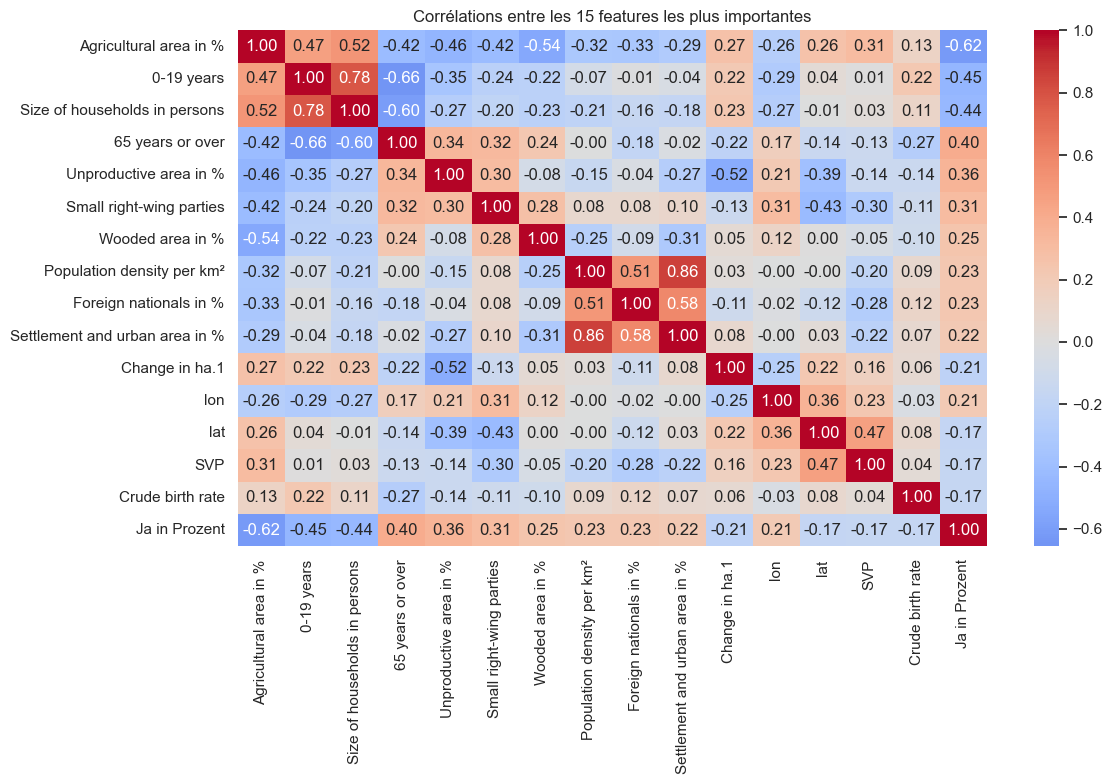

In [192]:
# Cellule 10 - Analyse des corrélations

# Calculer les corrélations avec la cible
correlations = df.select_dtypes(include=np.number).corr()["Ja in Prozent"]
correlations = correlations.drop("Ja in Prozent")
correlations = correlations.sort_values(ascending=False)

print("=== Top 10 features positivement corrélées ===")
print(correlations.head(10))

print("\n=== Top 10 features négativement corrélées ===")
print(correlations.tail(10))

# Heatmap des 15 features les plus corrélées
top_features = correlations.abs().sort_values(ascending=False).head(15).index.tolist()
top_features.append("Ja in Prozent")

plt.figure(figsize=(12, 8))
sns.heatmap(
    df[top_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Corrélations entre les 15 features les plus importantes")
plt.tight_layout()
plt.savefig("../figures/correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## Sauvegarde du dataset final
On sauvegarde le dataset fusionné et nettoyé pour l'utiliser dans les notebooks des modèles.
On fait la même chose pour le test.

In [196]:
# Cellule 11 - Sauvegarde du dataset final

# Sauvegarde du train fusionné
df.to_csv("../data/train_final.csv", index=False)

# Appliquer les mêmes merges sur le test
df_test = test.copy()
df_test = df_test.merge(demo,     on="commune_id", how="left")
df_test = df_test.merge(revenus,  on="commune_id", how="left")
df_test = df_test.merge(geo,      on="commune_id", how="left")
df_test = df_test.merge(ref_prev, on="commune_id", how="left")

# Sauvegarde du test fusionné
df_test.to_csv("../data/test_final.csv", index=False)

print(f" Train final sauvegardé : {df.shape}")
print(f" Test final sauvegardé  : {df_test.shape}")

 Train final sauvegardé : (1559, 67)
 Test final sauvegardé  : (669, 66)
